In [20]:
# %% [markdown]
# ## Gain-Scheduled Controller Simulation and Data Analysis (CcaS/CcaR TCS)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
from pathlib import Path
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

from model_and_controller_equations.run_all_controllers import run_control
from model_and_controller_equations.run_constant import run_constant
from signal_analysis import analyze_signal

In [21]:
## Experimental Data Processing 


# Load experimental fluorescence datasets
data1 = pd.read_csv('experiment_data/P-FL_OD_run_data_042325.csv')
data2 = pd.read_csv('experiment_data/P-FL_OD_run_data_040625.csv')

# Extract experimental replicates
P1_data1 = data1[['SP1_1', 'SP1_2', 'SP1_3', 'SP1_4', 'SP1_5', 'SP1_6']].to_numpy()
P2_data1 = data1[['SP2_1', 'SP2_2', 'SP2_3', 'SP2_4', 'SP2_5', 'SP2_6']].to_numpy()

P1_data2 = data2[['SP1_1', 'SP1_2', 'SP1_3']].to_numpy()
P2_data2 = data2[['SP2_1', 'SP2_2', 'SP2_3']].to_numpy()

green_data1 = data1[['G1']].to_numpy()
green_data2 = data2[['G1', 'G2', 'G3']].to_numpy()
red_data1 = data1[['R1']].to_numpy()
red_data2 = data2[['R1', 'R2', 'R3']].to_numpy()

# Truncate all data to shared minimum length
min_len = min(P1_data1.shape[0], P1_data2.shape[0])
P1_data1 = P1_data1[:min_len]; P2_data1 = P2_data1[:min_len]
P1_data2 = P1_data2[:min_len]; P2_data2 = P2_data2[:min_len]
green_data1 = green_data1[:min_len]; green_data2 = green_data2[:min_len]
red_data1 = red_data1[:min_len]; red_data2 = red_data2[:min_len]

# %%
# Merge all experimental replicates
P1_all = np.hstack((P1_data1, P1_data2))
P2_all = np.hstack((P2_data1, P2_data2))
green_all = np.hstack((green_data1, green_data2))
red_all = np.hstack((red_data1, red_data2))

# Compute means and standard deviations
P1_mean = np.mean(P1_all, axis=1)
P1_std = np.std(P1_all, axis=1)
P2_mean = np.mean(P2_all, axis=1)
P2_std = np.std(P2_all, axis=1)
green_mean = np.mean(green_all, axis=1)
green_std = np.std(green_all, axis=1)
red_mean = np.mean(red_all, axis=1)
red_std = np.std(red_all, axis=1)

# Normalize scale using green max
green_max = np.max(green_mean)

# Normalize experimental data
P1_mean_norm = P1_mean / green_max
P1_std_norm = P1_std / green_max
P2_mean_norm = P2_mean / green_max
P2_std_norm = P2_std / green_max
green_mean_norm = green_mean / green_max
green_std_norm = green_std / green_max
red_mean_norm = red_mean / green_max
red_std_norm = red_std / green_max

In [22]:
# Some User Defined Inputs
# Time parameters
interval = 10
time_exp = np.arange(interval, (min_len + 1) * interval, interval)
t_final = 16 * 60

# Setpoints from experiments
st_pt_1 = 11500
st_pt_2 = 18500


# Color dictionary
color_dict = {
    'set_point_1': '#6759d4',
    'set_point_2': '#d9d9d9',
    'green': 'green',
    'red': 'red',
    'PID': 'black',
    'PID-GS': '#1f78b4', 
    'FF': '#dd3497',
    'PID-FF': '#fc8d62',
    'PID-GS-FF': '#03cea4'
}

# Labels for the adaptive controllers 
controller_labels = {
    'PID': 'PID',
    'PID-GS': 'aPID',
    'PID-GS-FF': 'aPID-FF'
}

In [23]:
## Load the Model Parameters 


p = pd.read_csv('parameters/TCS_params_guess_070225.csv').to_numpy()

p = p[:,2]

params = lmfit.Parameters()

params.add(name = 'k_green', value = p[0], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_red', value = p[1], min = 1e0, max = 1e4, vary = 1)
params.add(name = 'b_green', value = p[2], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'b_red', value = p[3], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'k_sp_b', value = p[4], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_sp_u', value = p[5], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'k_rp_b', value = p[6], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_rp_u', value = p[7], min = 1e-4, max = 1e4, vary = 1)

params.add(name = 'beta', value = p[8], min = 1e-1, max = 500, vary = 1)
params.add(name = 'l0', value = p[9], min = 0, max = 0.5, vary = 1)
params.add(name = 'Kc', value = p[10], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_m', value = p[11], min = 0.05, max = 0.35, vary = 1)
params.add(name = 'k_tl', value = p[12], min = 0.05, max = 10, vary = 1)
params.add(name = 'k_tli_b', value = p[13], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'k_tli_u', value = p[14], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'd_p', value = p[15], min = 1e-6, max = 1e-1, vary = 1)
params.add(name = 'k_fold', value = p[16], min = 0.05, max = 0.3, vary = 1)
params.add(name = 'b_fold', value = p[17], min = 0.1, max = 2, vary = 1)
params.add(name = 'n_gamma', value = p[18], min = 0.05, max = 0.9, vary = 1)
params.add(name = 'R_max', value = p[19], min = 1e0, max = 1e4, vary = 1)

params.add(name = 'S_0', value = p[20], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'R_0', value = p[21], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Sp_0', value = p[22], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Rp_0', value = p[23], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'mRNA_0', value = p[24], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'P_0', value = p[25], min = 1e-4, max = 1e4, vary = 1)
params.add(name = 'Pm_0', value = p[26], min = 1e-4, max = 1e4, vary = 1)


params.add(name = 'k_gr', value = p[27], vary = 0)
params.add(name = 'C_max', value = p[28], vary = 0)
params.add(name = 'C_0', value = p[29], vary = 0)

params.add(name = 'n_tcs', value = p[30], min = 0.1, max = 5, vary = 1)

# define initial conditions and solve the ODEs

x0 = np.zeros(11)

x0[0] = p[20] # S
x0[1] = p[22]# Sp
x0[2] = p[21] # R
x0[3] = p[23] # Rp
x0[4] = 0 # Ac
x0[5] = p[24] # mRNA
x0[6] = 0 # Ctic
x0[7] = p[25] # Unfolded Protein 
x0[8] = p[26] # Folded Protein 
x0[9] = p[29] # Initial Cell count
x0[10] = 0 # Initial Integral Error

t_final = 960

In [24]:
# Simulate constant inputs (open loop) without any disturbance for baseline measurement

time_green_no_perturbn, _, sol_green_no_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=0)
time_red_no_perturbn, _, sol_red_no_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=0)
time_dark_no_perturbn, _, sol_dark_no_perturbn = run_constant(t_final, x0, params, constant_input = 'dark', growth_perturb=0)

st_pt_1_model = st_pt_1 * (np.max(sol_green_no_perturbn[:,8]))/green_max
st_pt_2_model = st_pt_2 * (np.max(sol_green_no_perturbn[:,8]))/green_max

### Simulation of different controller stratgeies for disturbance rejection

In [25]:
# Controller parameters

# simulate the pre-run step under constant green light
def closest_index(timepoints, target):
    tp = np.asarray(timepoints)
    i = np.searchsorted(tp, target, side="left")
    if i == 0:
        return 0
    if i == len(tp):
        return len(tp) - 1
    return i-1 if (target - tp[i-1]) <= (tp[i] - target) else i

t_rerun = 100
i_rerun = closest_index(time_green_no_perturbn, t_rerun)
x0 = sol_green_no_perturbn[i_rerun, :] # update the initial condition based on the pre-run

# Convert the units of gains and setpoints in the experiment to simulation units using the scaling factor
scaling_factor = (green_max/(np.max(sol_green_no_perturbn[:,8]))) * (1/60) 

pid_gain = 0.032 * scaling_factor
FF_gain = 0.8 * scaling_factor
PID_FF_gain = 0.8 * scaling_factor

tolerence_percentage = 0.05 # if X, then tolerence band is X * max(dynamic range)


# perturbation parameters
perturb_percent = 80 # If the sample is diluted by X%, the final OD equals the original (pre-dilution) OD multiplied by (100 − X)/100.
perturb_time = 480 # perturbation happens at this time (post the pre-run)
new_t_final = 16*60 # new experiment end time after perturbation


# Simulate constant inputs (open loop)
time_green_with_perturbn, _, sol_green_with_perturbn = run_constant(t_final, x0, params, constant_input = 'green', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)

time_red_with_perturbn, _, sol_red_with_perturbn = run_constant(t_final, x0, params, constant_input = 'red', growth_perturb=1,
                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                 new_t_final=new_t_final)


# Simulate disturbance rejection using Gain Scheduled PID, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID_GS, ctrl_SP2_PID_to_PID_GS, sol_SP2_PID_to_PID_GS, t_green_on_SP2_PID_to_PID_GS,  opt_times_SP2_PID_to_PID_GS = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID-GS",
                                                                print_perturb_message=True)

# # Simulate disturbance rejection using plain Feed Forward (FF), with pre-disturbance controller being plain PID. Equilibrium point is SP2
# t_SP2_PID_to_FF, ctrl_SP2_PID_to_FF, sol_SP2_PID_to_FF, t_green_on_SP2_PID_to_FF,  opt_times_SP2_PID_to_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
#                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
#                                                                 new_t_final=new_t_final,
#                                                                 initial_controller="PID",switch_to_controller="FF", FF_gain=FF_gain,
#                                                                 print_perturb_message=True)

# # Simulate disturbance rejection using combined PID-FF, with pre-disturbance controller being plain PID. Equilibrium point is SP2
# t_SP2_PID_to_PID_FF, ctrl_SP2_PID_to_PID_FF, sol_SP2_PID_to_PID_FF, t_green_on_SP2_PID_to_PID_FF,  opt_times_SP2_PID_to_PID_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
#                                                                 perturb_percent=perturb_percent, perturb_time=perturb_time,
#                                                                 new_t_final=new_t_final,
#                                                                 initial_controller="PID",switch_to_controller="PID-FF", FF_gain=PID_FF_gain,
#                                                                 print_perturb_message=True)

# Simulate disturbance rejection using combined PID-GS-FF, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID_GS_FF, ctrl_SP2_PID_to_PID_GS_FF, sol_SP2_PID_to_PID_GS_FF, t_green_on_SP2_PID_to_PID_GS_FF,  opt_times_SP2_PID_to_PID_GS_FF = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID-GS-FF", FF_gain=PID_FF_gain,
                                                                print_perturb_message=True)


# Simulate disturbance rejection using plain PID, with pre-disturbance controller being plain PID. Equilibrium point is SP2
t_SP2_PID_to_PID, ctrl_SP2_PID_to_PID, sol_SP2_PID_to_PID, t_green_on_SP2_PID_to_PID,  opt_times_SP2_PID_to_PID = run_control('PID-growth-perturb', t_final, st_pt_2_model, x0, params, gain=pid_gain,
                                                                perturb_percent=perturb_percent, perturb_time=perturb_time,
                                                                new_t_final=new_t_final,
                                                                initial_controller="PID",switch_to_controller="PID",
                                                                print_perturb_message=True)

Perturbing now
Perturbation applied at time 480 to bring to 12.719626168224298 minutes
Perturbing now
Perturbation applied at time 480 to bring to 12.719626168224298 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 12.667310943928673 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 12.667310943928673 minutes
Perturbing now, applying the PID-growth-perturb algorithm
Perturbation applied at time 480.0 to bring to 12.667310943928673 minutes


In [26]:
# Normalize simulation and experimental outputs
green_sim_norm = sol_green_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
red_sim_norm = sol_red_with_perturbn[:,8] / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_GS_norm = np.array(ctrl_SP2_PID_to_PID_GS) / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_GS_FF_norm = np.array(ctrl_SP2_PID_to_PID_GS_FF) / np.max(sol_green_no_perturbn[:,8])
ctrl_SP2_PID_to_PID_norm = np.array(ctrl_SP2_PID_to_PID) / np.max(sol_green_no_perturbn[:,8])

dynamic_range_norm = np.max(sol_green_no_perturbn[:,8] - sol_red_no_perturbn[:,8])  / np.max(sol_green_no_perturbn[:,8])

time_extent = min((max(time_green_with_perturbn), max(time_red_with_perturbn), max(t_SP2_PID_to_PID_GS)))

# extract growth profiles 
growth_green_with_perturbn = sol_green_with_perturbn[:,9] 
growth_red_with_perturbn = sol_red_with_perturbn[:,9] 

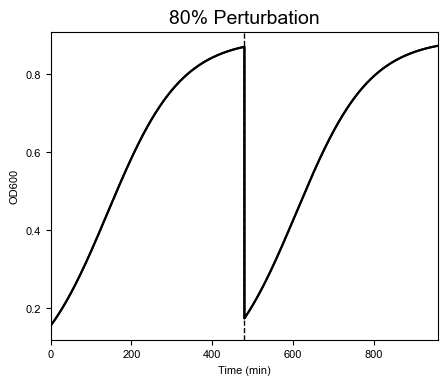

In [27]:
# Plot the growht perturbation 

fig, ax = plt.subplots(figsize=(5, 4))

# Style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10
})
# Line width and alpha
lwd = 2
alp = 0.3

ax.plot(time_green_with_perturbn, growth_green_with_perturbn/8e8, 'k')
ax.plot(time_red_with_perturbn, growth_red_with_perturbn/8e8, 'k')
ax.set_xlabel('Time (min)')
ax.set_ylabel('OD600')
ax.set_xlim(0, time_extent)


ax.set_title(f"{perturb_percent}% Perturbation")

ax.axvline(x=perturb_time, color='black', linestyle='--', linewidth=1)

In [28]:
def compute_performance_metric(ts_array, ITAE_array):
    """Computes a combined performance metric from settling times (ts) and ITAE.
    """
    ts = np.asarray(ts_array, dtype=float)
    itae = np.asarray(ITAE_array, dtype=float)

    if ts.shape != itae.shape:
        raise ValueError("ts_array and ITAE_array must have the same shape")
    
    min_perturb_time = 6 * 60 # the culture should grow for at least 6 hours before perturbation
     
    # itae max should be the integrated error if the system never settles within tolerence and we have a constant error equal to the tolerence band
    itae_max = tolerence_percentage * dynamic_range_norm * (new_t_final - min_perturb_time) * (new_t_final - min_perturb_time)/2
    ts_max = new_t_final - min_perturb_time

    ts_norm = ts/ts_max
    itae_norm = itae/itae_max

    metric = np.sqrt(ts_norm**2 + itae_norm**2)
    return metric

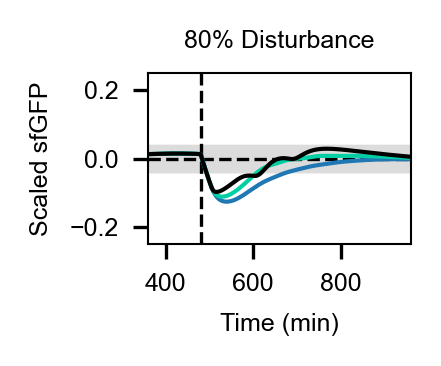

In [29]:
# %%
# Scaled disturbance plot
# Fully customizable styling for this plot

scaled_disturbance_cfg = {
    'figsize': (1.45, 1.2),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'label_fontsize': 6,
    'title_fontsize': 6,
    'legend_fontsize': 6,
    'tick_fontsize': 6,
    'line_width': 1.0,
    'tol_linewidth': 0.5,
    'perturb_linewidth': 0.8,
    'axis_linewidth': 0.5,
    'legend_loc': 'lower right',
    'legend_bbox_to_anchor': (1, 0),
    'legend_borderpad': 0.1,
    'legend_labelspacing': 0.2,
    'legend_handletextpad': 0.3,
    'legend_handlelength': 1.2,
    'tol_alpha': 0.90,
    'ylim': (-0.5, 0.5),
    'right_margin': 0.75
}

plt.rcParams.update({
    'font.family': scaled_disturbance_cfg['font_family'],
    'font.size': scaled_disturbance_cfg['base_fontsize'],
    'axes.labelsize': scaled_disturbance_cfg['label_fontsize'],
    'axes.titlesize': scaled_disturbance_cfg['title_fontsize'],
    'legend.fontsize': scaled_disturbance_cfg['legend_fontsize']
})

# scaling is done as: (setpoint - signal)
fig, ax = plt.subplots(
    figsize=scaled_disturbance_cfg['figsize'],
    dpi=scaled_disturbance_cfg['dpi']
)

# Tolerance band
tol_band_norm = dynamic_range_norm * tolerence_percentage

upper_tol_SP2 = np.ones_like(t_SP2_PID_to_PID_GS) * tol_band_norm
lower_tol_SP2 = np.ones_like(t_SP2_PID_to_PID_GS) * (-tol_band_norm)

# Horizontal set point
ax.axhline(
    y=0,
    color='k',
    linestyle='--',
    linewidth=scaled_disturbance_cfg['perturb_linewidth']
)


band = ax.fill_between(
    t_SP2_PID_to_PID_GS,
    lower_tol_SP2,
    upper_tol_SP2,
    color=color_dict['set_point_2'],
    alpha=scaled_disturbance_cfg['tol_alpha'],
    linewidth=0
)
band.set_rasterized(True)

# Vertical line to indicate time of perturbation
ax.axvline(
    x=perturb_time,
    color='black',
    linestyle='--',
    linewidth=scaled_disturbance_cfg['perturb_linewidth']
)

# Model predictions
ax.plot(
    t_SP2_PID_to_PID_GS,
    ctrl_SP2_PID_to_PID_GS_norm - st_pt_2 / green_max,
    color=color_dict['PID-GS'],
    linewidth=scaled_disturbance_cfg['line_width'],
    label='PID-GS'
)


ax.plot(
    t_SP2_PID_to_PID_GS_FF,
    ctrl_SP2_PID_to_PID_GS_FF_norm - st_pt_2 / green_max,
    color=color_dict['PID-GS-FF'],
    linewidth=scaled_disturbance_cfg['line_width'],
    label='PID-GS-FF'
)

ax.plot(
    t_SP2_PID_to_PID,
    ctrl_SP2_PID_to_PID_norm - st_pt_2 / green_max,
    color=color_dict['PID'],
    linewidth=scaled_disturbance_cfg['line_width'],
    label='PID'
)

# Axes
ax.set_xlabel('Time (min)', fontsize=scaled_disturbance_cfg['label_fontsize'])
ax.set_ylabel('Scaled sfGFP', fontsize=scaled_disturbance_cfg['label_fontsize'])
# ax.set_title(
#     rf"$\rho$ = {perturb_percent}%, Disturbance at {perturb_time} min",
#     fontsize=scaled_disturbance_cfg['title_fontsize']
# )
ax.set_title(
    rf"{perturb_percent}% Disturbance",
    fontsize=scaled_disturbance_cfg['title_fontsize']
)

ax.set_ylim(-0.25, 0.25)
ax.set_xlim(360, new_t_final)

# Legend
# ax.legend(
#     loc=scaled_disturbance_cfg['legend_loc'],
#     frameon=False,
#     bbox_to_anchor=scaled_disturbance_cfg['legend_bbox_to_anchor'],
#     borderpad=scaled_disturbance_cfg['legend_borderpad'],
#     labelspacing=scaled_disturbance_cfg['legend_labelspacing'],
#     handletextpad=scaled_disturbance_cfg['legend_handletextpad'],
#     handlelength=scaled_disturbance_cfg['legend_handlelength'],
#     fontsize=scaled_disturbance_cfg['legend_fontsize'],
#     ncol=1
# )

# Spine control
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(scaled_disturbance_cfg['axis_linewidth'])

# Ticks
ax.tick_params(axis='both', which='major', labelsize=scaled_disturbance_cfg['tick_fontsize'])

# Layout
fig.subplots_adjust(right=scaled_disturbance_cfg['right_margin'])
plt.tight_layout()

# Save if needed
#plt.savefig('figures/controller_comparison_'+str(perturb_percent)+'_percent_smallbox.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig('figures/controller_comparison_'+str(perturb_percent)+'_percent_with_legend_smallbox.svg', format='svg', dpi=300, bbox_inches='tight', transparent=True)

## Robustness Analysis

In [30]:
# =========================
# User-defined Monte Carlo inputs
# =========================

n_monte_carlo = 1000
random_seed = 1

# Disturbance-condition grid.
perturb_percents = [80]
perturb_times = [480]

new_t_final = 16 * 60

controllers_sorted = [
    "PID",
    "PID-GS",
    "PID-GS-FF",
]

# By default, sample every lmfit parameter whose vary flag is True.
#
# To sample only selected parameters, replace this with:
#
# parameters_to_sample = [
#     "k_green",
#     "k_red",
#     "beta",
#     "d_m",
# ]
# Initial-condition parameters must NOT be randomized.
initial_condition_parameters = {
    "S_0",
    "R_0",
    "Sp_0",
    "Rp_0",
    "mRNA_0",
    "P_0",
    "Pm_0",
    "C_0",
}

parameters_to_sample = [
    name for name in params
    if params[name].vary
    and name not in initial_condition_parameters
]

# Default sampling interval:
#
# nominal parameter value +/- uniform_relative_half_width
#
# For example, 0.20 means the parameter is sampled uniformly
# between 80% and 120% of its nominal value.
uniform_relative_half_width = 0.15

# Used when a nominal parameter value equals exactly zero.
uniform_absolute_half_width_for_zero = 1.0e-6

# Optional parameter-specific bounds.
#
# Any entry here overrides uniform_relative_half_width for that parameter.
#
# Example:
#
# parameter_uniform_bounds = {
#     "k_green": (
#         0.8 * params["k_green"].value,
#         1.2 * params["k_green"].value,
#     ),
#     "beta": (50.0, 150.0),
# }
parameter_uniform_bounds = {}


# Controller gains in experimental units.
pid_gain_experiment = 0.032
FF_gain_experiment = 0.8
PID_FF_gain_experiment = 0.8

# Options:
#
# "shared":
# Use the earliest perturbation time to define the common normalization
# denominator for M. This is consistent across all conditions.
#
# "per_condition":
# Use the perturbation time of each individual condition.
metric_normalization = "shared"

# Common interpolation grid used for calculating the mean trajectory.
trajectory_plot_dt = 2.0

trajectory_plot_time = np.arange(
    0.0,
    new_t_final + 0.5 * trajectory_plot_dt,
    trajectory_plot_dt,
)

# =========================
# User-defined plot styling
# =========================

# Colors of individual Monte Carlo trajectories.
random_trajectory_colors = {
    "PID": "#bdbdbd",
    "PID-GS": "#9ecae1",
    "PID-GS-FF": "#9ee5d2",
}

# Colors of mean Monte Carlo trajectories.
mean_trajectory_colors = {
    "PID": color_dict["PID"],
    "PID-GS": color_dict["PID-GS"],
    "PID-GS-FF": color_dict["PID-GS-FF"],
}

# Lower alpha gives more transparent random trajectories.
random_trajectory_alpha = 0.2

# Alpha of the darker mean trajectory.
mean_trajectory_alpha = 1

random_trajectory_linewidth = 0.5
mean_trajectory_linewidth = 1

# Plot limits. Set robustness_ylim = None for automatic limits.
robustness_ylim = (-0.45, 0.45)
robustness_xlim = (0, new_t_final)

subplot_size = (2.0, 1.6)
plot_dpi = 300
save_plot_format = "svg"

# True displays figures in the notebook.
# False only saves the figures.
show_figures = True

# =========================
# Output directories
# =========================

results_directory = Path("robustness_results")
figures_directory = Path("figures/robustness")

results_directory.mkdir(
    parents=True,
    exist_ok=True,
)

figures_directory.mkdir(
    parents=True,
    exist_ok=True,
)

ROBUSTNESS_CSV_PATH = (
    results_directory
    / "monte_carlo_robustness_results_20_percent_perturbation.csv"
)

SAMPLED_PARAMETERS_CSV_PATH = (
    results_directory
    / "monte_carlo_sampled_parameters.csv"
)

In [31]:
def _finite_parameter_limit(value, fallback):
    """
    Convert an lmfit parameter limit to a finite usable value.
    """
    value = float(value)

    if np.isfinite(value):
        return value

    return fallback


def get_uniform_sampling_bounds(
    nominal_params,
    parameter_name,
    relative_half_width,
    explicit_bounds,
    zero_half_width,
):
    """
    Determine the lower and upper uniform sampling bounds for one
    parameter.

    The requested interval is clipped to the minimum and maximum
    bounds stored in the original lmfit.Parameters object.
    """
    par = nominal_params[parameter_name]
    nominal_value = float(par.value)

    if parameter_name in explicit_bounds:
        low, high = explicit_bounds[parameter_name]

        low = float(low)
        high = float(high)

    else:
        half_width = (
            abs(nominal_value)
            * float(relative_half_width)
        )

        if half_width == 0:
            half_width = float(zero_half_width)

        low = nominal_value - half_width
        high = nominal_value + half_width

    if low > high:
        low, high = high, low

    lmfit_min = _finite_parameter_limit(
        par.min,
        -np.inf,
    )

    lmfit_max = _finite_parameter_limit(
        par.max,
        np.inf,
    )

    low = max(low, lmfit_min)
    high = min(high, lmfit_max)

    if not np.isfinite(low) or not np.isfinite(high):
        raise ValueError(
            f"Finite sampling bounds are required for "
            f"{parameter_name}. Resolved bounds were "
            f"({low}, {high})."
        )

    if low > high:
        raise ValueError(
            f"Sampling bounds for {parameter_name} do not "
            f"overlap its lmfit bounds "
            f"[{par.min}, {par.max}]."
        )

    return low, high


def sample_model_parameters(
    nominal_params,
    rng,
    parameter_names,
    relative_half_width,
    explicit_bounds,
    zero_half_width,
):
    """
    Create one sampled lmfit.Parameters realization.

    Each selected parameter is sampled independently from a uniform
    distribution.
    """
    sampled_params = nominal_params.copy()
    sampled_values = {}

    for parameter_name in parameter_names:
        if parameter_name not in nominal_params:
            raise KeyError(
                f"{parameter_name!r} is not present in params."
            )

        low, high = get_uniform_sampling_bounds(
            nominal_params=nominal_params,
            parameter_name=parameter_name,
            relative_half_width=relative_half_width,
            explicit_bounds=explicit_bounds,
            zero_half_width=zero_half_width,
        )

        if np.isclose(low, high):
            sampled_value = low
        else:
            sampled_value = rng.uniform(
                low,
                high,
            )

        sampled_params[parameter_name].set(
            value=float(sampled_value)
        )

        sampled_values[parameter_name] = float(
            sampled_value
        )

    return sampled_params, sampled_values


def build_model_initial_condition(sampled_params):
    """
    Recreate x0 using the same state ordering as the original notebook.
    """
    x0_sample = np.zeros(
        11,
        dtype=float,
    )

    x0_sample[0] = sampled_params["S_0"].value
    x0_sample[1] = sampled_params["Sp_0"].value
    x0_sample[2] = sampled_params["R_0"].value
    x0_sample[3] = sampled_params["Rp_0"].value
    x0_sample[4] = 0.0
    x0_sample[5] = sampled_params["mRNA_0"].value
    x0_sample[6] = 0.0
    x0_sample[7] = sampled_params["P_0"].value
    x0_sample[8] = sampled_params["Pm_0"].value
    x0_sample[9] = sampled_params["C_0"].value
    x0_sample[10] = 0.0

    return x0_sample


def safe_metric_after_disturbance(
    err,
    t,
    perturb_time,
    tol_band,
    dyn_range,
    settle_cap,
):
    """
    Calculate the existing signal-analysis metrics using an
    error-to-setpoint trajectory.

    The setpoint is zero because err is already defined as:

        normalized output - normalized setpoint

    Settling time is also returned relative to the disturbance time.
    """
    err = np.asarray(
        err,
        dtype=float,
    )

    t = np.asarray(
        t,
        dtype=float,
    )

    # Analyze only the disturbance-rejection portion.
    post_mask = t >= float(perturb_time)

    err_post = err[post_mask]

    # Reset time so tau = 0 exactly at the disturbance.
    t_post = (
        t[post_mask]
        - float(perturb_time)
    )

    settle_cap_post = (
        float(settle_cap)
        - float(perturb_time)
    )

    rise_t, settle_t, overshoot, ITAE = analyze_signal(
    err_post,
    t_post,
    0.0,
    tol_band,
    dyn_range,
    settle_time_cap=settle_cap_post,
    perturbed_time=0.0,
    )

    if settle_t is None:
        t_settle_after = settle_cap_post

    elif not np.isfinite(float(settle_t)):
        t_settle_after = settle_cap_post

    else:
        t_settle_after = float(settle_t)

    settling_time_abs = (
        float(perturb_time)
        + t_settle_after
    )

    if rise_t is None:
        rise_time_value = np.nan
    else:
        rise_time_value = float(rise_t)

    return {
        "rise_time": rise_time_value,
        "settling_time_abs": settling_time_abs,
        "t_settle_after": t_settle_after,
        "overshoot": float(overshoot),
        "ITAE": float(ITAE),
    }


def compute_performance_metric(
    ts_array,
    ITAE_array,
    dyn_range,
    perturb_time,
):
    """
    Compute M using the same Euclidean combination of normalized
    settling time and normalized ITAE used in the original sweep.

    M = sqrt(
        normalized settling time squared
        +
        normalized ITAE squared
    )
    """
    ts = np.asarray(
        ts_array,
        dtype=float,
    )

    itae = np.asarray(
        ITAE_array,
        dtype=float,
    )

    if ts.shape != itae.shape:
        raise ValueError(
            "ts_array and ITAE_array must have the same shape."
        )

    if metric_normalization == "shared":
        reference_time = float(
            min(perturb_times)
        )

    elif metric_normalization == "per_condition":
        reference_time = float(
            perturb_time
        )

    else:
        raise ValueError(
            "metric_normalization must be "
            "'shared' or 'per_condition'."
        )

    available_time = (
        float(new_t_final)
        - reference_time
    )

    if available_time <= 0:
        raise ValueError(
            "new_t_final must be later than the "
            "M normalization time."
        )

    ts_max = available_time

    itae_max = (
        float(tolerence_percentage)
        * float(dyn_range)
        * available_time**2
        / 2.0
    )

    if itae_max <= 0:
        raise ValueError(
            "The ITAE normalization denominator "
            "must be positive."
        )

    if not np.isfinite(itae_max):
        raise ValueError(
            "The ITAE normalization denominator "
            "must be finite."
        )

    ts_norm = ts / ts_max
    itae_norm = itae / itae_max

    metric_M = np.sqrt(
        ts_norm**2
        + itae_norm**2
    )

    return metric_M


def interpolate_trajectory(
    t,
    err,
    common_time,
):
    """
    Interpolate a successful trajectory onto the common plotting grid.
    """
    t = np.asarray(
        t,
        dtype=float,
    )

    err = np.asarray(
        err,
        dtype=float,
    )

    valid = (
        np.isfinite(t)
        & np.isfinite(err)
    )

    t = t[valid]
    err = err[valid]

    if t.size < 2:
        return np.full_like(
            common_time,
            np.nan,
            dtype=float,
        )

    order = np.argsort(t)

    t = t[order]
    err = err[order]

    # Remove duplicate time values before interpolation.
    t_unique, unique_indices = np.unique(
        t,
        return_index=True,
    )

    err_unique = err[unique_indices]

    interpolated = np.interp(
        common_time,
        t_unique,
        err_unique,
        left=np.nan,
        right=np.nan,
    )

    return interpolated


def controller_specific_kwargs(
    controller,
    pid_gain_sample,
    FF_gain_sample,
    PID_FF_gain_sample,
):
    """
    Return run_control keyword arguments for each controller.
    """
    common = {
        "gain": pid_gain_sample,
        "initial_controller": "PID",
        "switch_to_controller": controller,
        "print_perturb_message": False,
    }

    if controller == "PID-GS-FF":
        common["FF_gain"] = PID_FF_gain_sample

    elif controller not in {
        "PID",
        "PID-GS",
    }:
        raise ValueError(
            f"Unsupported controller: {controller}"
        )

    return common


def make_result_row(
    monte_carlo_id,
    perturb_percent,
    perturb_time,
    controller,
    sampled_values,
    status,
    error_message="",
    **metrics,
):
    """
    Create one run-level result row while retaining the sampled
    parameter values.
    """
    row = {
        "monte_carlo_id": int(monte_carlo_id),
        "perturb_percent": float(perturb_percent),
        "perturb_time": float(perturb_time),
        "controller": controller,
        "status": status,
        "error_message": str(error_message)[:500],
    }

    row.update(metrics)

    row.update({
        f"param_{name}": float(value)
        for name, value in sampled_values.items()
    })

    return row

In [32]:
# Resolve and display the actual bounds used by the sampler.

sampling_bounds_rows = []

for parameter_name in parameters_to_sample:
    low, high = get_uniform_sampling_bounds(
        nominal_params=params,
        parameter_name=parameter_name,
        relative_half_width=uniform_relative_half_width,
        explicit_bounds=parameter_uniform_bounds,
        zero_half_width=uniform_absolute_half_width_for_zero,
    )

    sampling_bounds_rows.append({
        "parameter": parameter_name,
        "nominal_value": float(
            params[parameter_name].value
        ),
        "uniform_low": low,
        "uniform_high": high,
        "lmfit_min": float(
            params[parameter_name].min
        ),
        "lmfit_max": float(
            params[parameter_name].max
        ),
    })

sampling_bounds_table = pd.DataFrame(
    sampling_bounds_rows
)

display(sampling_bounds_table)

,parameter,nominal_value,uniform_low,uniform_high,lmfit_min,lmfit_max
0,k_green,0.8000,0.68000,0.920000,0.000100,10000.00
1,k_red,1.3000,1.10500,1.495000,1.000000,10000.00
2,b_green,0.0300,0.02550,0.034500,0.000100,10000.00
3,b_red,1.0000,1.00000,1.150000,1.000000,10000.00
4,k_sp_b,0.0500,0.04250,0.057500,0.000100,10000.00
5,k_sp_u,25.0000,21.25000,28.750000,0.000100,10000.00
6,k_rp_b,55.0000,46.75000,63.250000,0.000100,10000.00
7,k_rp_u,0.0800,0.06800,0.092000,0.000100,10000.00
8,beta,28.0000,23.80000,32.200000,0.100000,500.00
9,l0,0.0000,0.00000,0.000001,0.000000,0.50


In [33]:
# =========================
# Run the Monte Carlo robustness analysis
# =========================

# ============================================================
# Fixed nominal references for disturbance-rejection analysis
# ============================================================

nominal_norm_factor = float(
    np.max(sol_green_no_perturbn[:, 8])
)

nominal_dynamic_range_norm = float(
    dynamic_range_norm
)

nominal_tol_band_norm = float(
    tolerence_percentage
    * nominal_dynamic_range_norm
)

setpoint_norm_fixed = float(
    st_pt_2_model / nominal_norm_factor
)

# ============================================================
# Generate ONE nominal pre-disturbance trajectory for each
# disturbance time. All Monte Carlo runs start from this state.
# ============================================================

nominal_prefix_cache = {}

for pt in perturb_times:

    (
        t_pre,
        ctrl_pre,
        sol_pre,
        t_green_pre,
        opt_times_pre,
    ) = run_control(
        "PID-growth-perturb",
        pt,
        st_pt_2_model,
        np.asarray(x0, dtype=float).copy(),
        params.copy(),
        gain=pid_gain,

        # Zero disturbance at the end of the prefix.
        perturb_percent=0.0,
        perturb_time=pt,
        new_t_final=pt,

        initial_controller="PID",
        switch_to_controller="PID",
        print_perturb_message=False,
    )

    t_pre = np.asarray(t_pre, dtype=float)
    ctrl_pre = np.asarray(ctrl_pre, dtype=float)
    sol_pre = np.asarray(sol_pre, dtype=float)

    # Sanity check: disturbance should occur only after the
    # nominal controller has reached the desired operating region.
    pre_error = (
        ctrl_pre[-1] / nominal_norm_factor
        - setpoint_norm_fixed
    )

    if abs(pre_error) > nominal_tol_band_norm:
        warnings.warn(
            f"At t={pt} min the nominal PID has not reached "
            f"the tolerance band before the disturbance. "
            f"Normalized error = {pre_error:.4g}."
        )

    nominal_prefix_cache[pt] = (
        t_pre,
        ctrl_pre,
        sol_pre,
    )

rng = np.random.default_rng(random_seed)

conditions = [
    (pp, pt)
    for pp in perturb_percents
    for pt in perturb_times
]

results = []
sampled_parameter_rows = []

# Stores interpolated trajectories for plotting.
trajectory_store = {
    controller: {
        condition: []
        for condition in conditions
    }
    for controller in controllers_sorted
}

for monte_carlo_id in range(n_monte_carlo):
    print(
        f"Monte Carlo realization "
        f"{monte_carlo_id + 1} of "
        f"{n_monte_carlo}"
    )

    sampled_params, sampled_values = (
        sample_model_parameters(
            nominal_params=params,
            rng=rng,
            parameter_names=parameters_to_sample,
            relative_half_width=uniform_relative_half_width,
            explicit_bounds=parameter_uniform_bounds,
            zero_half_width=(
                uniform_absolute_half_width_for_zero
            ),
        )
    )

    sampled_parameter_rows.append({
        "monte_carlo_id": monte_carlo_id,
        **{
            f"param_{name}": float(
                sampled_values[name]
            )
            for name in parameters_to_sample
        },
    })

    # ============================================================
    # Fixed references for disturbance-rejection robustness
    # ============================================================

    # All Monte Carlo trajectories use the same nominal
    # normalization, dynamic range, setpoint and controller tuning.
    norm_factor_sample = float(
        np.max(sol_green_no_perturbn[:, 8])
    )

    dynamic_range_norm_sample = float(
        dynamic_range_norm
    )

    tol_band_norm_sample = float(
        dynamic_range_norm
        * tolerence_percentage
    )

    st_pt_2_model_sample = st_pt_2_model

    setpoint_norm = (
        st_pt_2_model
        / norm_factor_sample
    )

    # Do NOT retune the controller for each uncertain plant.
    pid_gain_sample = pid_gain
    FF_gain_sample = FF_gain
    PID_FF_gain_sample = PID_FF_gain

    # ============================================
    # Simulate every disturbance and controller
    # ============================================

    for pp, pt in conditions:
        for controller in controllers_sorted:
            try:
                controller_kwargs = (
                    controller_specific_kwargs(
                        controller=controller,
                        pid_gain_sample=pid_gain_sample,
                        FF_gain_sample=FF_gain_sample,
                        PID_FF_gain_sample=(
                            PID_FF_gain_sample
                        ),
                    )
                )

                (
                    t_controller,
                    ctrl_controller,
                    sol_controller,
                    t_green_on_controller,
                    opt_times_controller,
                ) = run_control(
                    "PID-growth-perturb",
                    t_final,
                    st_pt_2_model,
                    x0.copy(),

                    # Nominal plant before disturbance.
                    params,

                    perturb_percent=pp,
                    perturb_time=pt,
                    new_t_final=new_t_final,

                    # Randomized plant only after disturbance.
                    params_after_perturb=sampled_params,

                    **controller_kwargs,
                )

                t_controller = np.asarray(
                    t_controller,
                    dtype=float,
                )

                ctrl_controller = np.asarray(
                    ctrl_controller,
                    dtype=float,
                )

                if len(t_controller) != len(
                    ctrl_controller
                ):
                    raise ValueError(
                        "Controller time and output "
                        "arrays have different lengths."
                    )

                ctrl_controller_norm = (
                    ctrl_controller
                    / norm_factor_sample
                )

                # Error relative to SP2.
                err_controller = (
                    ctrl_controller_norm
                    - setpoint_norm
                )

                metric_values = (
                    safe_metric_after_disturbance(
                        err=err_controller,
                        t=t_controller,
                        perturb_time=pt,
                        tol_band=tol_band_norm_sample,
                        dyn_range=(
                            dynamic_range_norm_sample
                        ),
                        settle_cap=new_t_final,
                    )
                )

                metric_M = float(
                    compute_performance_metric(
                        ts_array=[
                            metric_values[
                                "t_settle_after"
                            ]
                        ],
                        ITAE_array=[
                            metric_values["ITAE"]
                        ],
                        dyn_range=(
                            dynamic_range_norm_sample
                        ),
                        perturb_time=pt,
                    )[0]
                )

                # Determine this realization's pre-disturbance equilibrium.
                pre_disturbance_indices = np.where(
                    t_controller < pt
                )[0]

                if pre_disturbance_indices.size == 0:
                    raise ValueError(
                        "No pre-disturbance controller samples were found."
                    )

                equilibrium_norm = ctrl_controller_norm[
                    pre_disturbance_indices[-1]
                ]

                interpolated_trajectory = (
                    interpolate_trajectory(
                        t=t_controller,
                        err=err_controller,
                        common_time=(
                            trajectory_plot_time
                        ),
                    )
                )

                trajectory_store[
                    controller
                ][
                    (pp, pt)
                ].append(
                    interpolated_trajectory
                )

                results.append(
                    make_result_row(
                        monte_carlo_id=monte_carlo_id,
                        perturb_percent=pp,
                        perturb_time=pt,
                        controller=controller,
                        sampled_values=sampled_values,
                        status="ok",
                        error_message="",
                        metric_M=metric_M,
                        t_settle_after=(
                            metric_values[
                                "t_settle_after"
                            ]
                        ),
                        ITAE=metric_values["ITAE"],
                        rise_time=(
                            metric_values[
                                "rise_time"
                            ]
                        ),
                        overshoot=(
                            metric_values[
                                "overshoot"
                            ]
                        ),
                        settling_time_abs=(
                            metric_values[
                                "settling_time_abs"
                            ]
                        ),
                        norm_factor=(
                            norm_factor_sample
                        ),
                        dynamic_range_norm=(
                            dynamic_range_norm_sample
                        ),
                        tol_band_norm=(
                            tol_band_norm_sample
                        ),
                        pid_gain=pid_gain_sample,
                        FF_gain=FF_gain_sample,
                        PID_FF_gain=(
                            PID_FF_gain_sample
                        ),
                    )
                )

            except Exception as exc:
                error_text = (
                    f"{type(exc).__name__}: {exc}"
                )

                print(
                    f"  Failed: "
                    f"MC={monte_carlo_id}, "
                    f"perturb_percent={pp}, "
                    f"perturb_time={pt}, "
                    f"controller={controller}: "
                    f"{error_text}"
                )

                results.append(
                    make_result_row(
                        monte_carlo_id=monte_carlo_id,
                        perturb_percent=pp,
                        perturb_time=pt,
                        controller=controller,
                        sampled_values=sampled_values,
                        status="failed_controller",
                        error_message=error_text,
                        metric_M=np.nan,
                        t_settle_after=np.nan,
                        ITAE=np.nan,
                        rise_time=np.nan,
                        overshoot=np.nan,
                        settling_time_abs=np.nan,
                        norm_factor=(
                            norm_factor_sample
                        ),
                        dynamic_range_norm=(
                            dynamic_range_norm_sample
                        ),
                        tol_band_norm=(
                            tol_band_norm_sample
                        ),
                        pid_gain=pid_gain_sample,
                        FF_gain=FF_gain_sample,
                        PID_FF_gain=(
                            PID_FF_gain_sample
                        ),
                    )
                )

Monte Carlo realization 1 of 1000
Monte Carlo realization 2 of 1000
Monte Carlo realization 3 of 1000
Monte Carlo realization 4 of 1000
Monte Carlo realization 5 of 1000
Monte Carlo realization 6 of 1000
Monte Carlo realization 7 of 1000
Monte Carlo realization 8 of 1000
Monte Carlo realization 9 of 1000
Monte Carlo realization 10 of 1000
Monte Carlo realization 11 of 1000
Monte Carlo realization 12 of 1000
Monte Carlo realization 13 of 1000
Monte Carlo realization 14 of 1000
Monte Carlo realization 15 of 1000
Monte Carlo realization 16 of 1000
Monte Carlo realization 17 of 1000
Monte Carlo realization 18 of 1000
Monte Carlo realization 19 of 1000
Monte Carlo realization 20 of 1000
Monte Carlo realization 21 of 1000
Monte Carlo realization 22 of 1000
Monte Carlo realization 23 of 1000
Monte Carlo realization 24 of 1000
Monte Carlo realization 25 of 1000
Monte Carlo realization 26 of 1000
Monte Carlo realization 27 of 1000
Monte Carlo realization 28 of 1000
Monte Carlo realization 29 of

In [34]:
# Store all run-level metrics and sampled parameter realizations.

df_results = pd.DataFrame(
    results
)

df_sampled_parameters = pd.DataFrame(
    sampled_parameter_rows
)

df_results.to_csv(
    ROBUSTNESS_CSV_PATH,
    index=False,
)

df_sampled_parameters.to_csv(
    SAMPLED_PARAMETERS_CSV_PATH,
    index=False,
)

print(
    f"Saved run-level results to: "
    f"{ROBUSTNESS_CSV_PATH}"
)

print(
    f"Saved sampled parameters to: "
    f"{SAMPLED_PARAMETERS_CSV_PATH}"
)

status_summary = (
    df_results
    .groupby([
        "status",
        "controller",
    ])
    .size()
    .rename("count")
    .reset_index()
)

display(status_summary)

display(
    df_results.head()
)

Saved run-level results to: robustness_results/monte_carlo_robustness_results_20_percent_perturbation.csv
Saved sampled parameters to: robustness_results/monte_carlo_sampled_parameters.csv


,status,controller,count
0,ok,PID,1000
1,ok,PID-GS,1000
2,ok,PID-GS-FF,1000


,monte_carlo_id,perturb_percent,perturb_time,controller,status,error_message,metric_M,t_settle_after,ITAE,rise_time,...,param_d_m,param_k_tl,param_k_tli_b,param_k_tli_u,param_d_p,param_k_fold,param_b_fold,param_n_gamma,param_R_max,param_n_tcs
0,0,80.0,480.0,PID,ok,,0.383503,136.898990,1242.693095,0.0,...,0.273090,1.897839,43.461144,11.291501,0.000789,0.261032,0.970934,0.785019,3.714776,1.075109
1,0,80.0,480.0,PID-GS,ok,,0.690981,204.916265,2633.520960,0.0,...,0.273090,1.897839,43.461144,11.291501,0.000789,0.261032,0.970934,0.785019,3.714776,1.075109
2,0,80.0,480.0,PID-GS-FF,ok,,0.383698,130.636364,1310.972061,0.0,...,0.273090,1.897839,43.461144,11.291501,0.000789,0.261032,0.970934,0.785019,3.714776,1.075109
3,1,80.0,480.0,PID,ok,,2.324138,960.000000,5738.403725,0.0,...,0.280003,2.166010,41.356040,13.502272,0.000690,0.278787,0.987801,0.764650,4.169594,1.105790
4,1,80.0,480.0,PID-GS,ok,,0.507625,159.151515,1863.097203,0.0,...,0.280003,2.166010,41.356040,13.502272,0.000690,0.278787,0.987801,0.764650,4.169594,1.105790


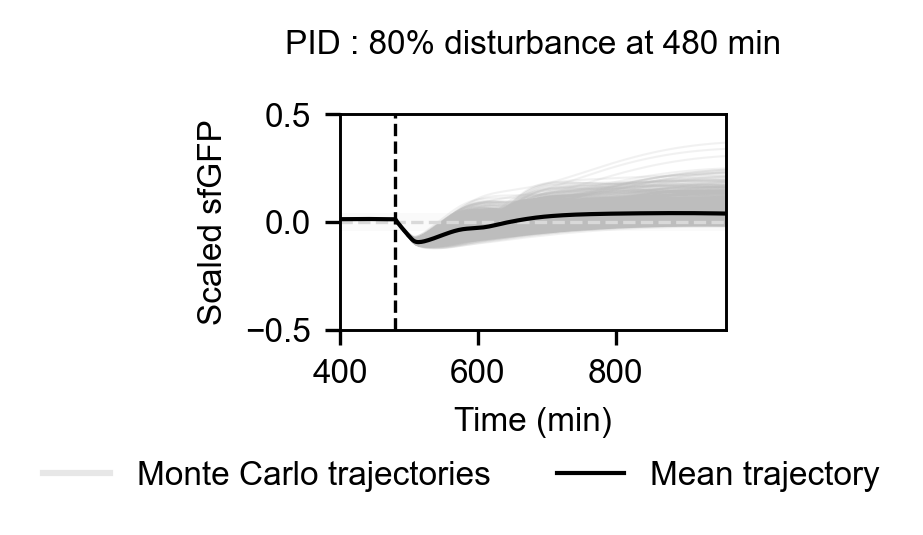

Saved: figures/robustness/monte_carlo_robustness_80_percent_perturbation_PID.svg


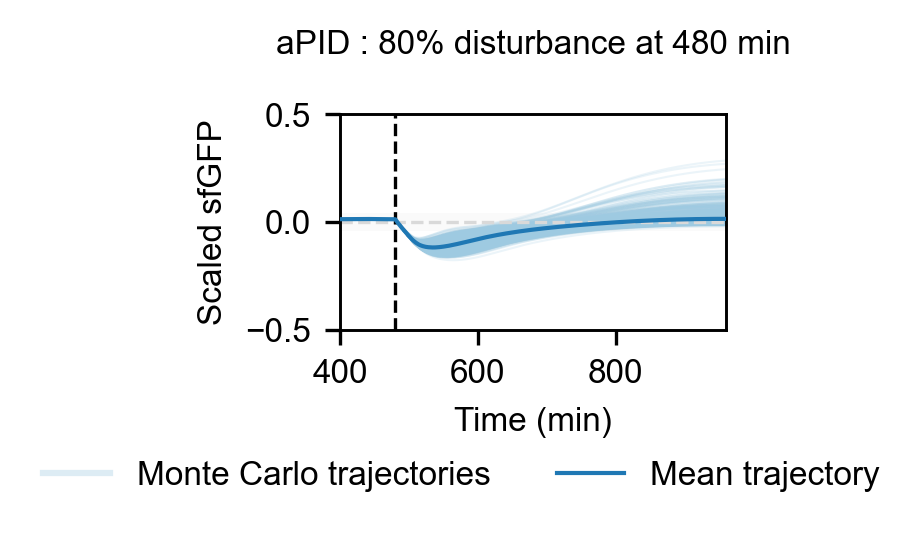

Saved: figures/robustness/monte_carlo_robustness_80_percent_perturbation_aPID.svg


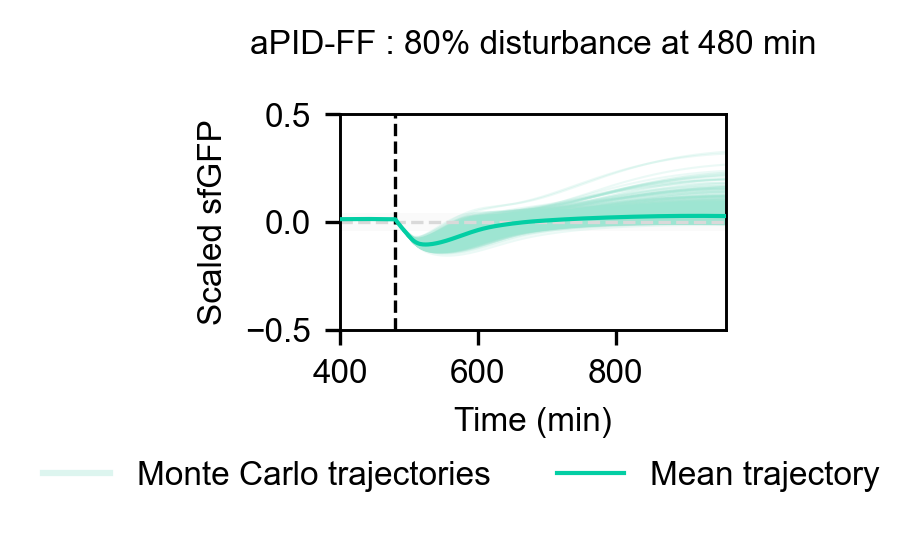

Saved: figures/robustness/monte_carlo_robustness_80_percent_perturbation_aPID-FF.svg


In [35]:
# =========================
# Plot one 2-D condition grid for each controller
# =========================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 8,
})

# Use the nominal tolerance band as a consistent visual reference
# in all Monte Carlo subplots.

nominal_norm_factor = np.max(
    sol_green_no_perturbn[:, 8]
)

nominal_dynamic_range_norm = (
    np.max(
        sol_green_no_perturbn[:, 8]
        - sol_red_no_perturbn[:, 8]
    )
    / nominal_norm_factor
)

nominal_tol_band_norm = (
    tolerence_percentage
    * nominal_dynamic_range_norm
)

for controller in controllers_sorted:
    fig, axes = plt.subplots(
        nrows=len(perturb_percents),
        ncols=len(perturb_times),
        figsize=(
            subplot_size[0]
            * len(perturb_times),
            subplot_size[1]
            * len(perturb_percents),
        ),
        sharex=True,
        sharey=True,
        squeeze=False,
        dpi=plot_dpi,
    )

    for i, pp in enumerate(
        perturb_percents
    ):
        for j, pt in enumerate(
            perturb_times
        ):
            ax = axes[i, j]

            curves = trajectory_store[
                controller
            ][
                (pp, pt)
            ]

            valid_curves = []

            # Plot each random Monte Carlo trajectory.
            for curve in curves:
                curve = np.asarray(
                    curve,
                    dtype=float,
                )

                if np.any(
                    np.isfinite(curve)
                ):
                    valid_curves.append(
                        curve
                    )

                    line = ax.plot(
                        trajectory_plot_time,
                        curve,
                        color=(
                            random_trajectory_colors[
                                controller
                            ]
                        ),
                        alpha=(
                            random_trajectory_alpha
                        ),
                        linewidth=(
                            random_trajectory_linewidth
                        ),
                    )[0]

                    # Rasterization keeps large SVG/PDF files manageable.
                    line.set_rasterized(
                        True
                    )

            # Plot the mean Monte Carlo trajectory.
            if len(valid_curves) > 0:
                stacked_curves = np.vstack(
                    valid_curves
                )

                mean_trajectory = np.nanmean(
                    stacked_curves,
                    axis=0,
                )

                ax.plot(
                    trajectory_plot_time,
                    mean_trajectory,
                    color=(
                        mean_trajectory_colors[
                            controller
                        ]
                    ),
                    alpha=(
                        mean_trajectory_alpha
                    ),
                    linewidth=(
                        mean_trajectory_linewidth
                    ),
                    label="Mean trajectory",
                    zorder=5,
                )

            # Zero represents the normalized setpoint.
            ax.axhline(
                0.0,
                color=color_dict[
                    "set_point_2"
                ],
                linestyle="--",
                linewidth=0.8,
            )

            # Nominal tolerance band.
            ax.fill_between(
                trajectory_plot_time,
                -nominal_tol_band_norm,
                nominal_tol_band_norm,
                color=color_dict[
                    "set_point_2"
                ],
                alpha=0.12,
                linewidth=0,
            )

            # Disturbance time.
            ax.axvline(
                pt,
                color="black",
                linestyle="--",
                linewidth=0.8,
            )

            ax.set_title(
                f"{controller_labels.get(controller, controller)} : " +
                f"{pp}% disturbance at "
                f"{pt} min\n"
            )

            ax.set_xlim(
                *robustness_xlim
            )

            if robustness_ylim is not None:
                ax.set_ylim(
                    *robustness_ylim
                )

            if i == (
                len(perturb_percents) - 1
            ):
                ax.set_xlabel(
                    "Time (min)"
                )

            if j == 0:
                ax.set_ylabel(
                    "Scaled sfGFP"
                )

            for spine in [
                "top",
                "right",
                "bottom",
                "left",
            ]:
                ax.spines[
                    spine
                ].set_linewidth(
                    0.7
                )

    random_handle = Line2D(
        [0],
        [0],
        color=(
            random_trajectory_colors[
                controller
            ]
        ),
        alpha=max(
            random_trajectory_alpha,
            0.35,
        ),
        linewidth=1.5,
        label="Monte Carlo trajectories",
    )

    mean_handle = Line2D(
        [0],
        [0],
        color=(
            mean_trajectory_colors[
                controller
            ]
        ),
        alpha=mean_trajectory_alpha,
        linewidth=(
            mean_trajectory_linewidth
        ),
        label="Mean trajectory",
    )

    fig.legend(
        handles=[
            random_handle,
            mean_handle,
        ],
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(
            0.5,
            -0.1,
        ),
    )

    fig.tight_layout()

    safe_controller = (
        controller.replace(
            "-",
            "_",
        )
    )

    output_path = (
        figures_directory
        / (
            f"monte_carlo_robustness_"
            f"{pp}_percent_perturbation_"
            f"{controller_labels[controller]}."
            f"{save_plot_format}"
        )
    )

    ax.set_xlim(400, 960)
    ax.set_ylim(-0.5, 0.5)

    fig.savefig(
        output_path,
        dpi=plot_dpi,
        bbox_inches="tight",
        transparent=True,
    )

    if show_figures:
        plt.show()
    else:
        plt.close(fig)

    print(
        f"Saved: {output_path}"
    )